In [13]:
from __future__ import annotations
from pathlib import Path 

import yaml, json, os, sys

import numpy as np, matplotlib.pyplot as plt
import igraph as ig, networkx as nx
import torch

from collections import deque 
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.colors as mcolors


ROOT = "/scratch/sleonard/MoE_circuits"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

In [ ]:
MODELS   = ["olmoe", "deepseek-v2-lite", "mixtral-8x7b"]
DATASETS = ["c4", "math", "code"]

dags: dict[tuple[str, str], dict] = {}
for m in MODELS:
    for d in DATASETS:
        path = os.path.join(config["result_path"], f"circuits/dag_{m}_{d}.pt")
        dags[(m, d)] = torch.load(path, map_location="cpu")

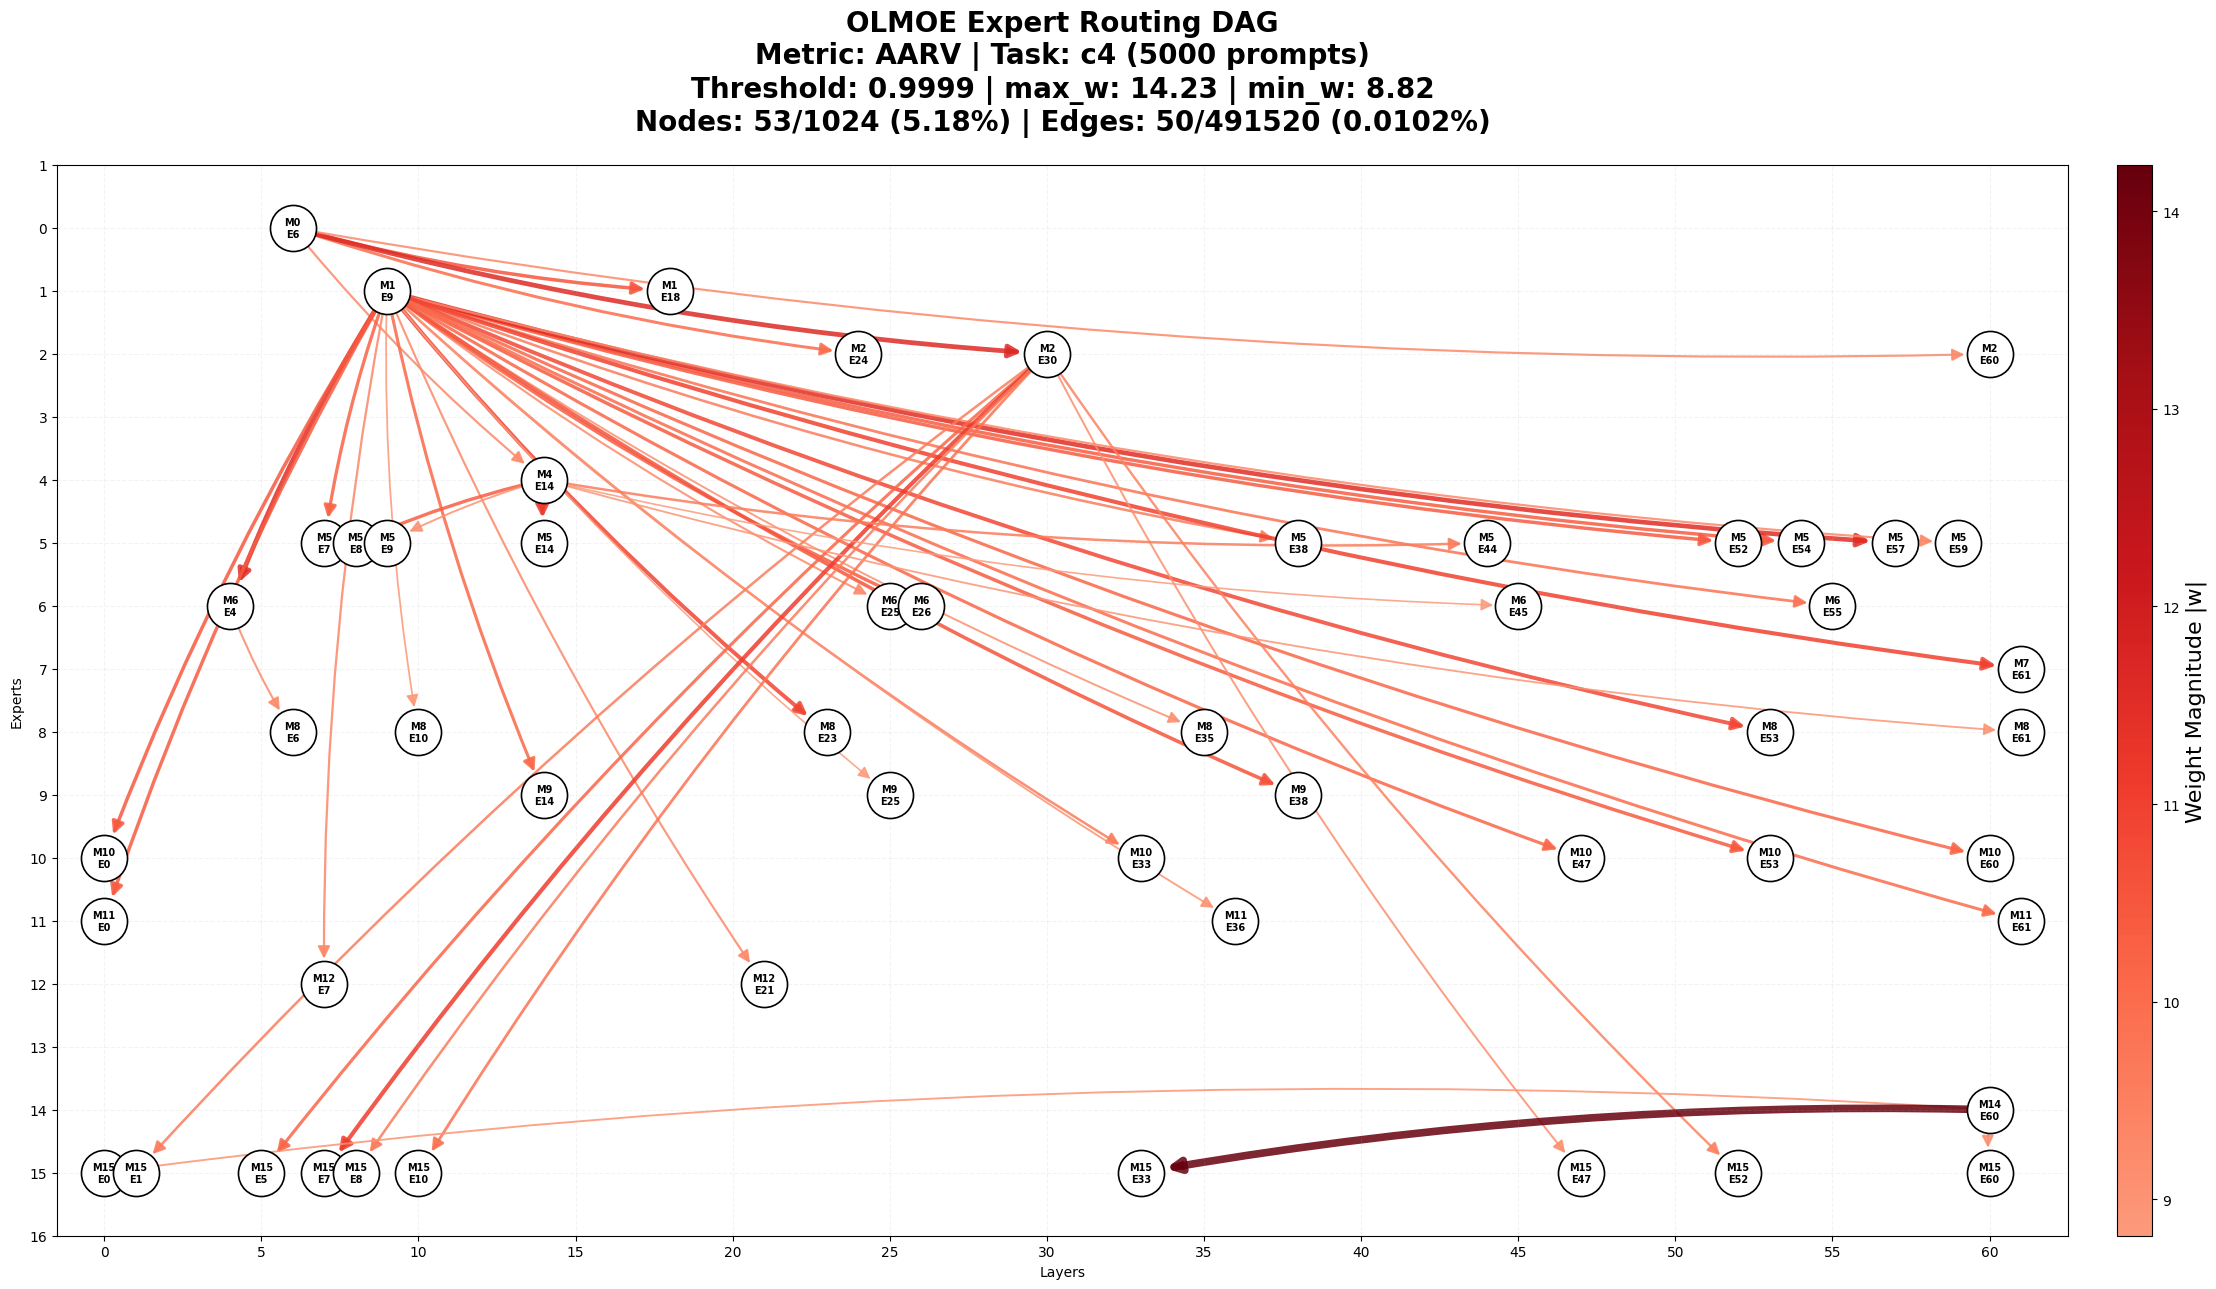

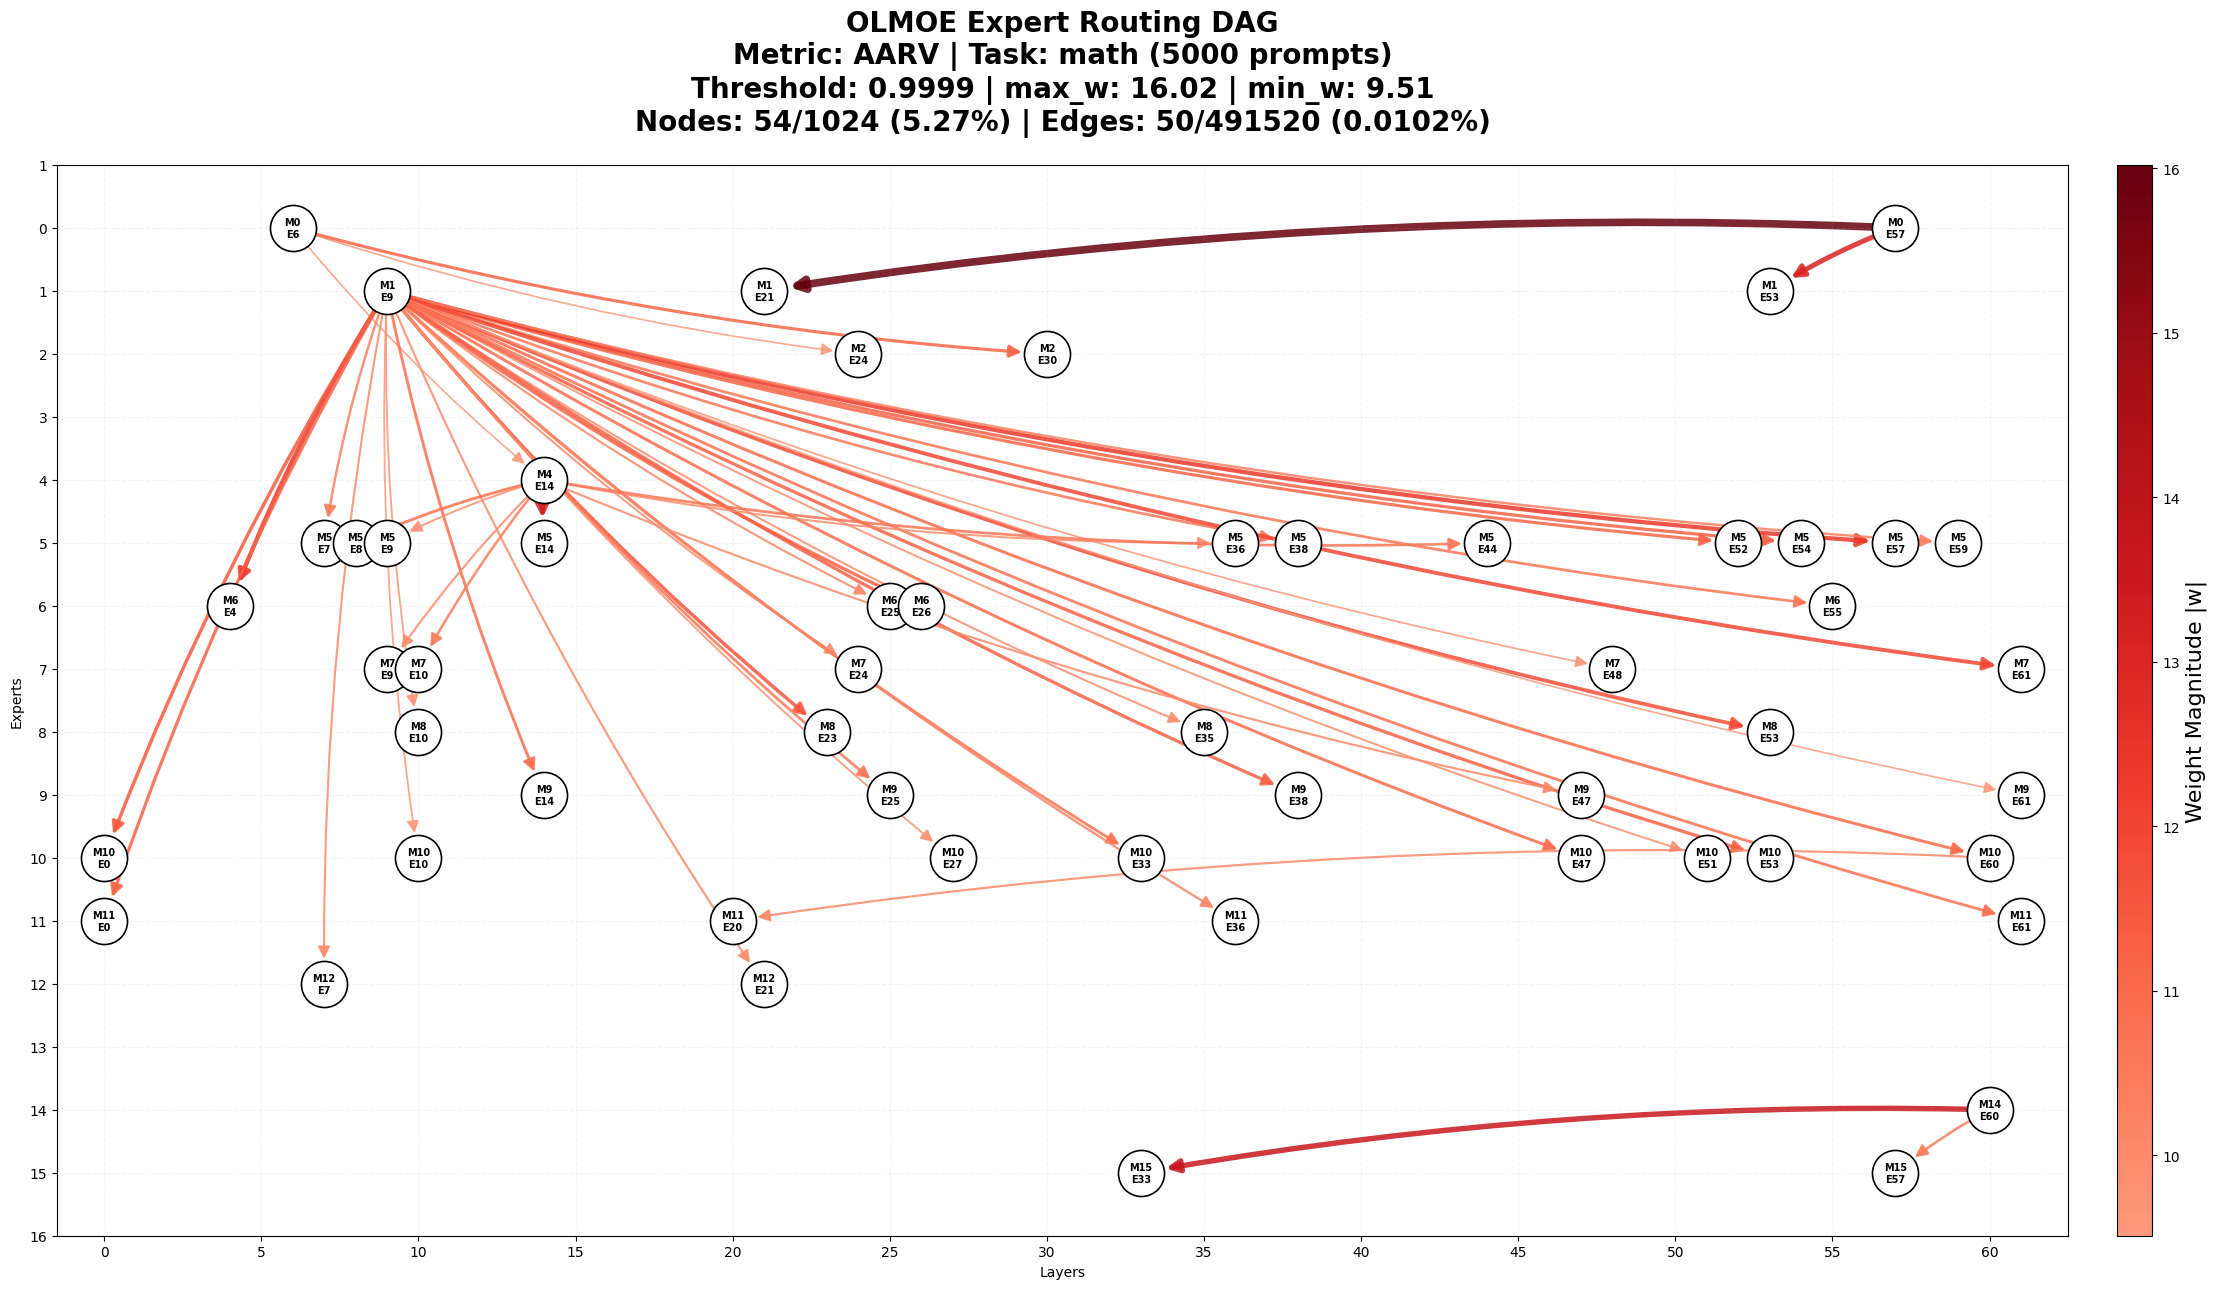

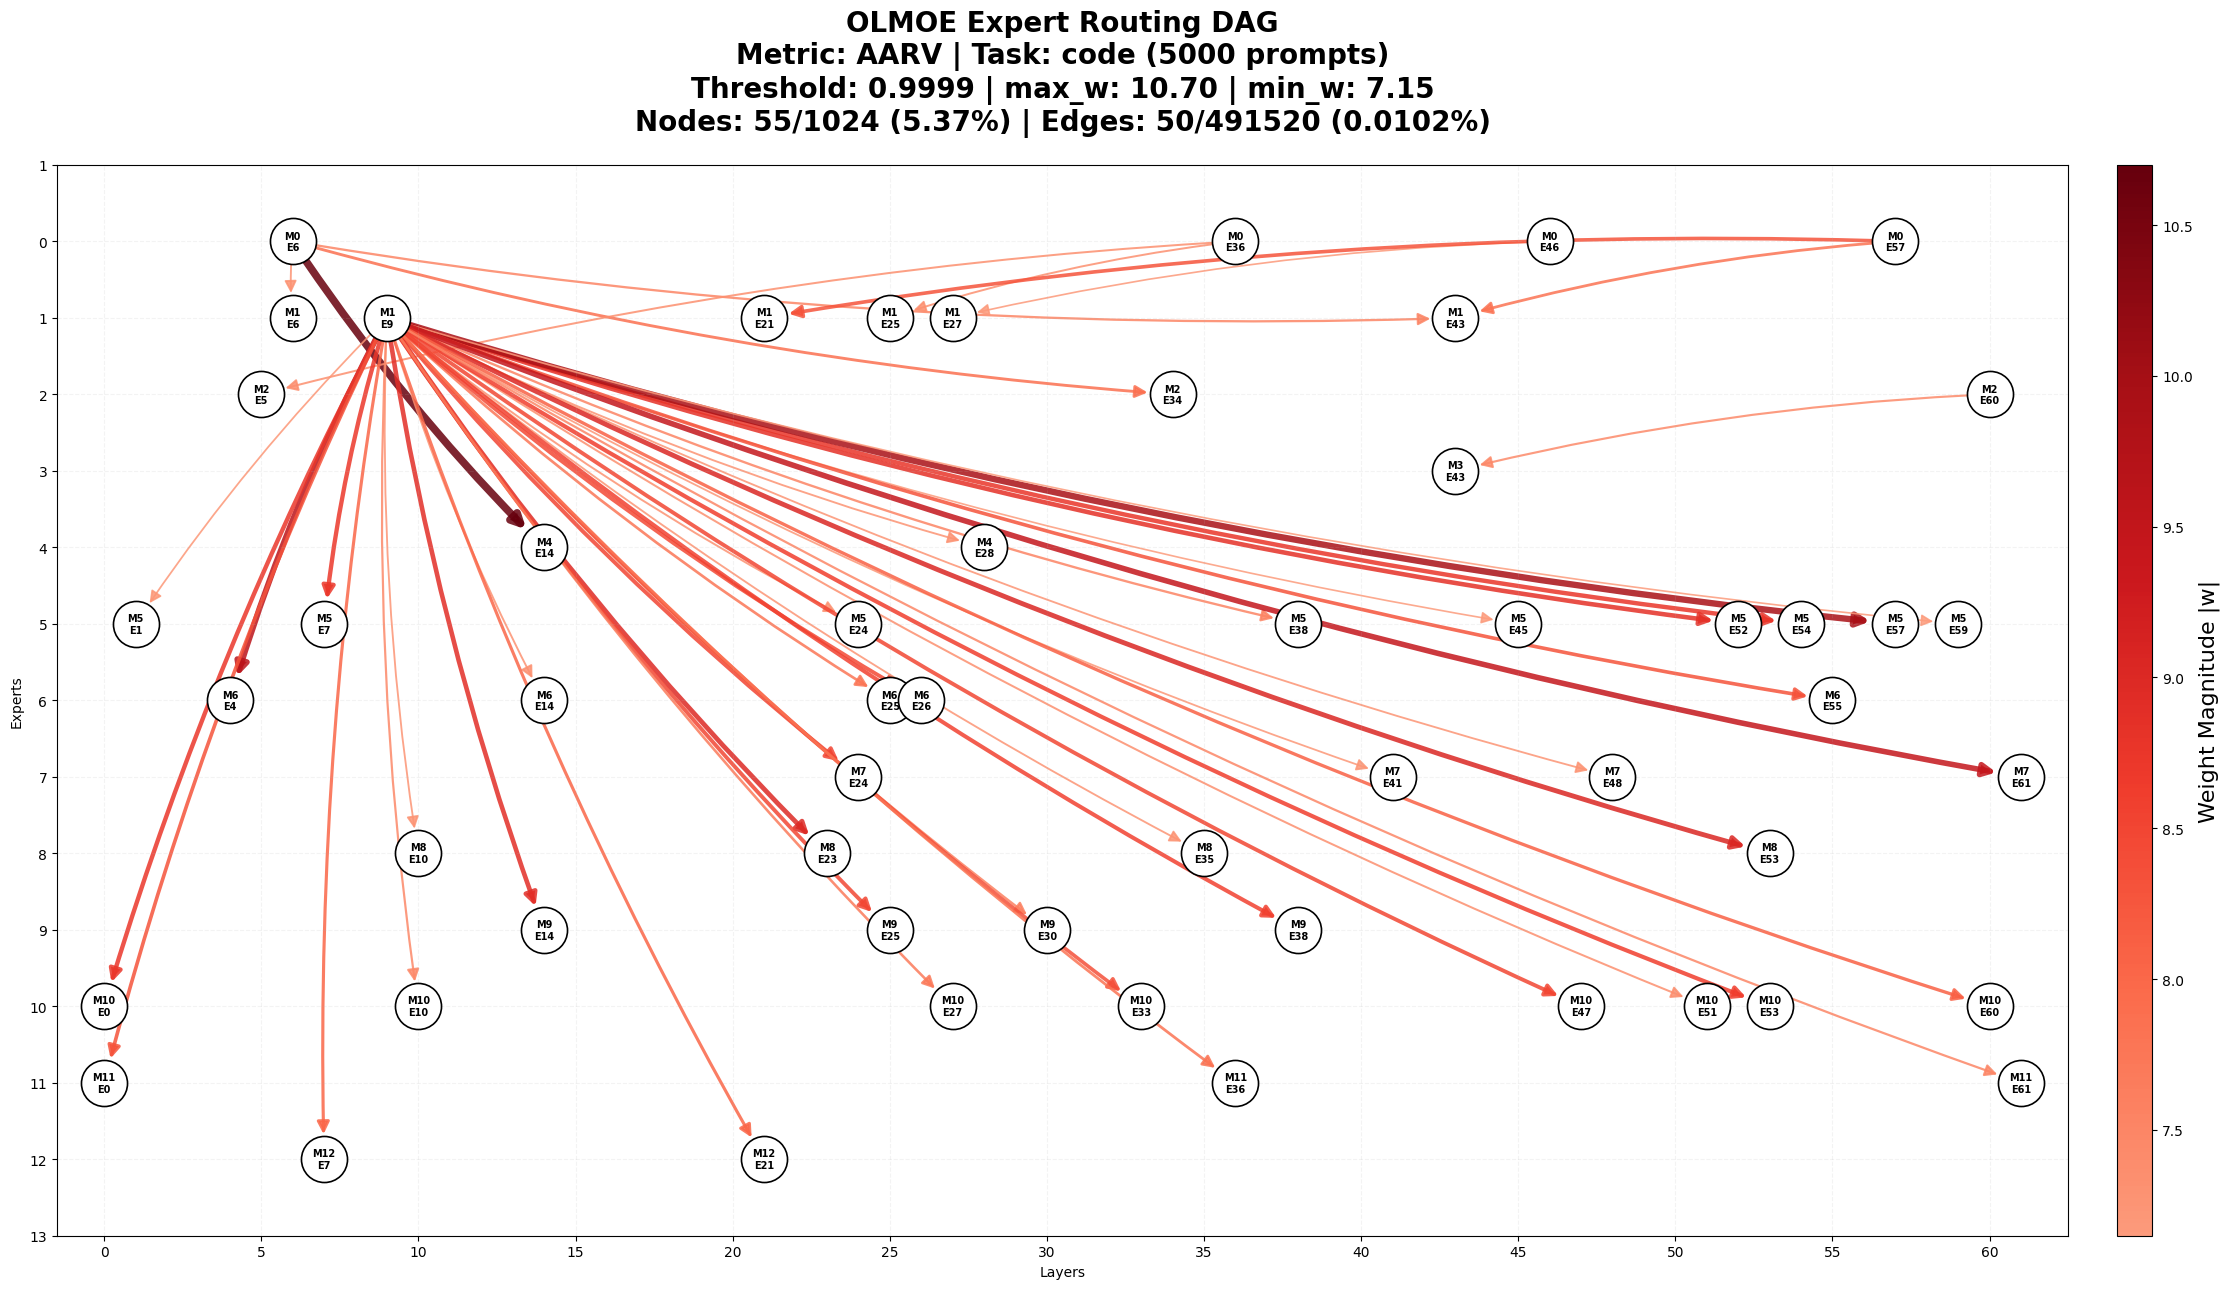

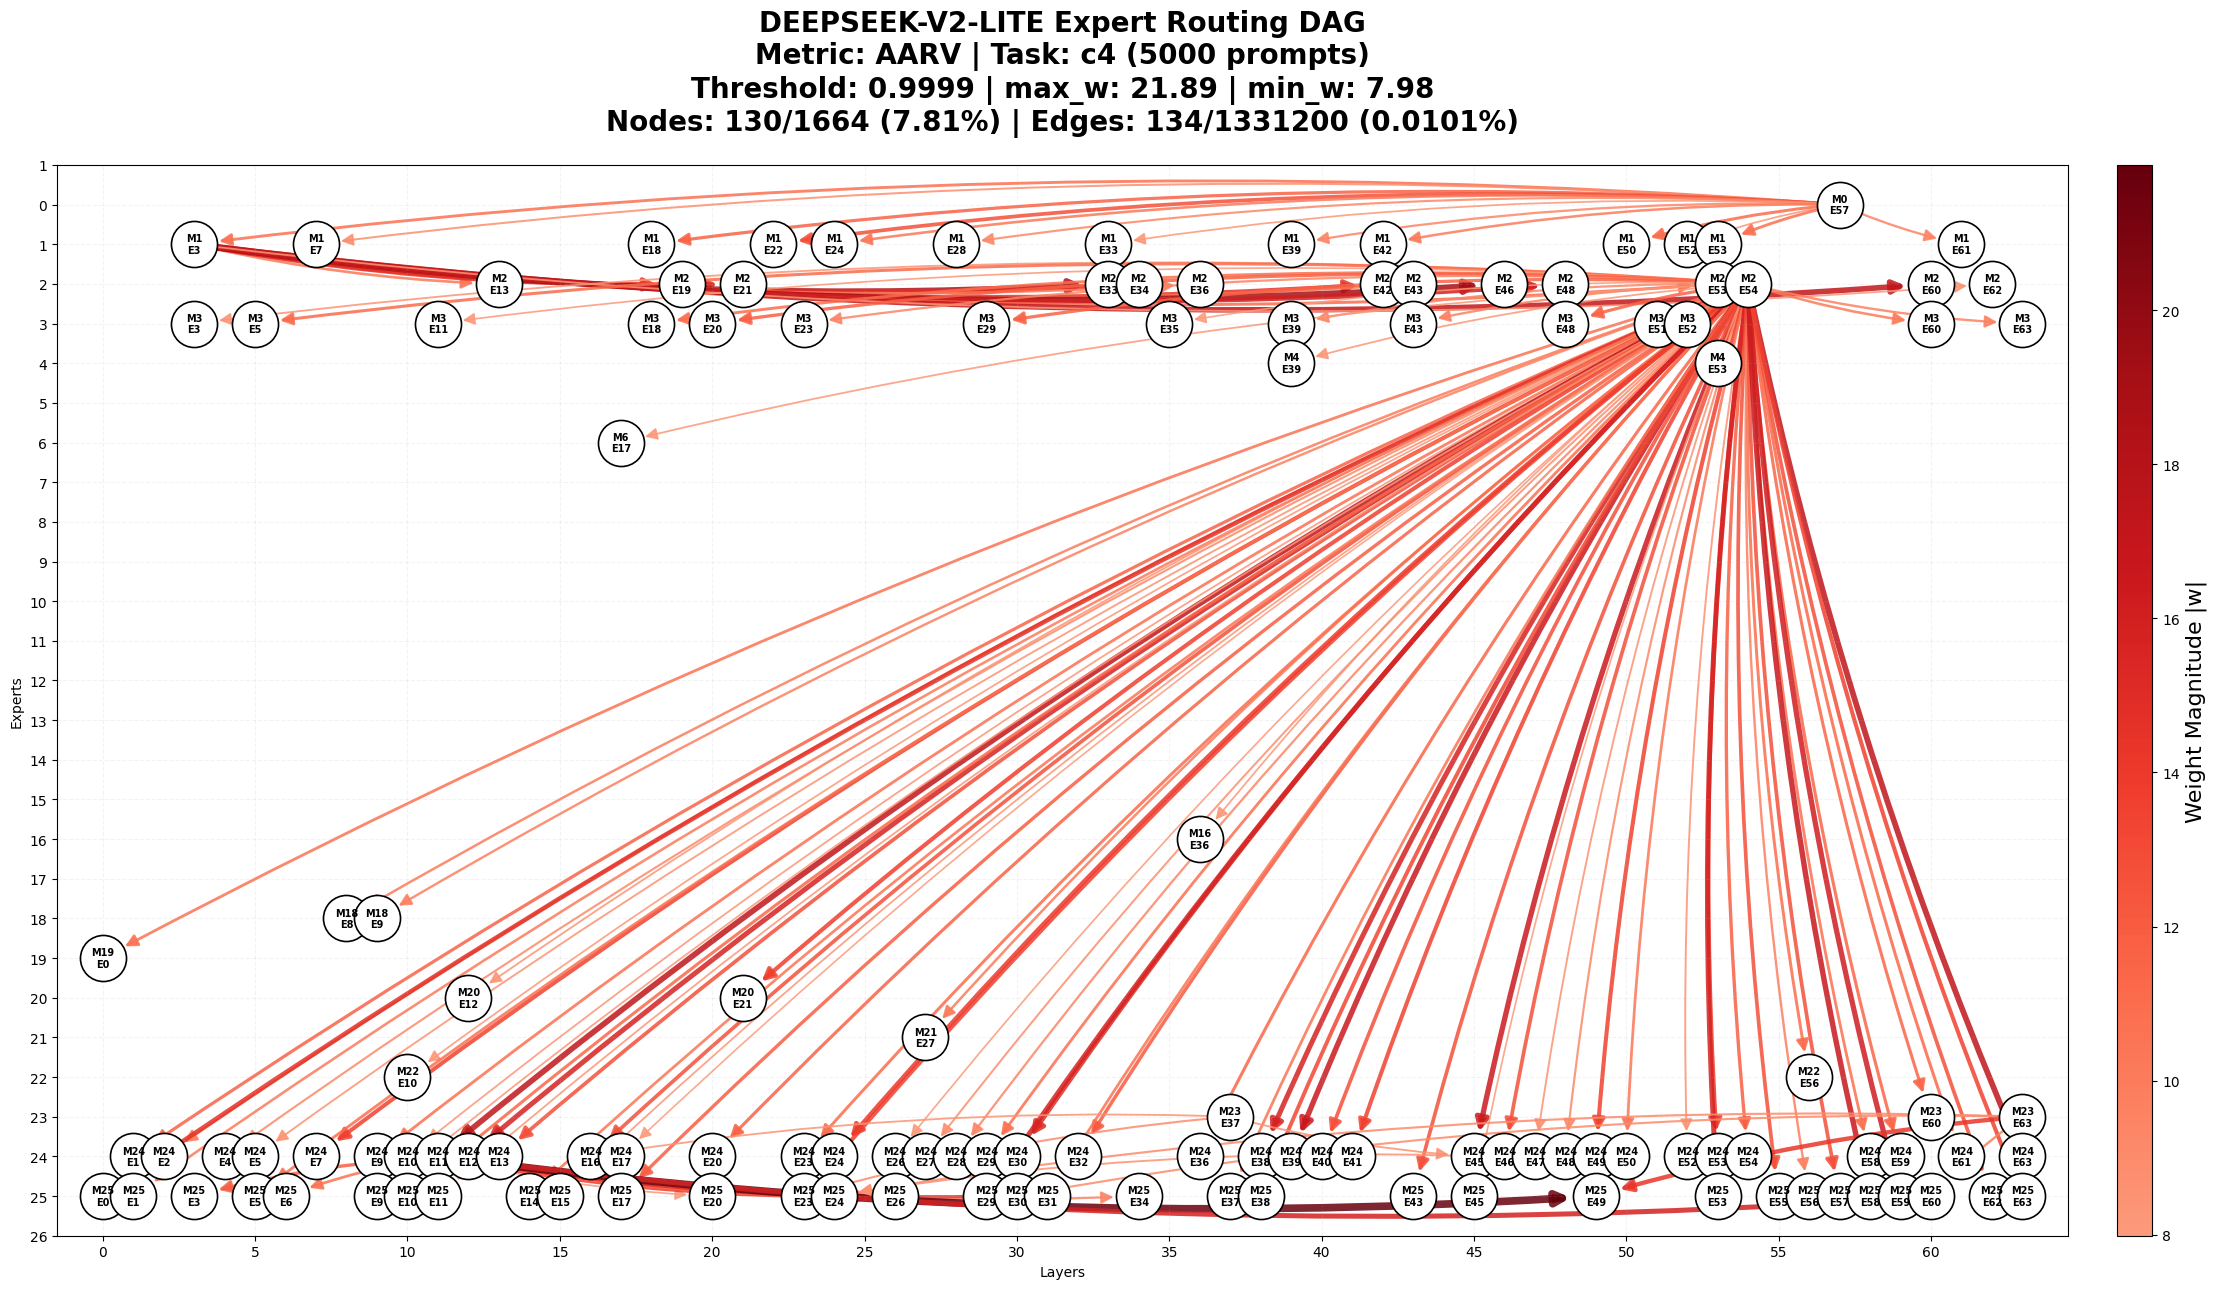

In [ ]:
from experiments.circuits.helper import get_thresholds, thresholding_routing_graph, show_enhanced_layered_graph

TARGET, Q = "AARV", 0.9999
for m in MODELS:
    for d in DATASETS: 
        dag = dags[(m, d)]
        t = get_thresholds(dag, TARGET, [Q])[Q]
        g = thresholding_routing_graph(dag, TARGET, t)
        show_enhanced_layered_graph(g, quantile=Q, target=TARGET, model=m, dataset=d, n_prompts=dag["n_prompts"])

In [ ]:
# --- Layer-pair mass (LPM) fingerprint: "where do edges live?" ---
# Sparsify each DAG (same threshold as the viz), bucket edges by relative
# depth (s/L, r/L) into an N_BUCKETS x N_BUCKETS grid, normalize to a
# probability distribution. Size-invariant by construction.
from experiments.circuits.helper import get_thresholds, layer_pair_mass, lpm_similarity

WEIGHT, Q, N_BUCKETS = "AARV", 0.9999, 8

M_dict = {}
for key, dag in dags.items():
    W = dag[WEIGHT]
    if isinstance(W, torch.Tensor):
        W = W.cpu().numpy().astype(np.float64)
    t = get_thresholds(dag, WEIGHT, [Q])[Q]
    Ws = np.where(np.abs(W) >= t, W, 0.0)
    M_dict[key] = layer_pair_mass(Ws, n_buckets=N_BUCKETS)

# Grid: rows = models, cols = datasets.
fig, axes = plt.subplots(len(MODELS), len(DATASETS), figsize=(11, 3.5 * len(MODELS)))
vmax = max(M.max() for M in M_dict.values())
for i, m in enumerate(MODELS):
    for j, d in enumerate(DATASETS):
        ax = axes[i, j] if len(MODELS) > 1 else axes[j]
        im = ax.imshow(M_dict[(m, d)], cmap="viridis", origin="upper", vmin=0, vmax=vmax)
        ax.set_title(f"{m}/{d}", fontsize=10)
        ax.set_xlabel("receiver bucket (r/L)")
        ax.set_ylabel("sender bucket (s/L)")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Layer-pair mass distributions ({N_BUCKETS}x{N_BUCKETS}, {WEIGHT}, q={Q})")
plt.tight_layout(); plt.show()

In [ ]:
# --- 9x9 LPM similarity matrix + 3-way block aggregates ---
keys = list(dags.keys())
n = len(keys)
LPM_COS = np.zeros((n, n))
LPM_TV  = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        LPM_COS[i, j] = lpm_similarity(M_dict[keys[i]], M_dict[keys[j]], metric="cosine")
        LPM_TV[i, j]  = lpm_similarity(M_dict[keys[i]], M_dict[keys[j]], metric="tv")

short = {"olmoe": "olmo", "deepseek-v2-lite": "deep", "mixtral-8x7b": "mixt"}
labels = [f"{short.get(k[0], k[0][:4])}/{k[1]}" for k in keys]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (M, title) in zip(axes, [
    (LPM_COS, f"LPM cosine ({N_BUCKETS}x{N_BUCKETS}, {WEIGHT}, q={Q})"),
    (LPM_TV,  f"LPM TV-sim ({N_BUCKETS}x{N_BUCKETS}, {WEIGHT}, q={Q})"),
]):
    off_diag = M[~np.eye(n, dtype=bool)]
    vmin = float(off_diag.min())
    im = ax.imshow(M, cmap="viridis", vmin=vmin, vmax=1.0)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
    mid = (vmin + 1.0) / 2
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                    color="white" if M[i, j] < mid else "black", fontsize=6)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
plt.tight_layout(); plt.show()


# Block aggregates: within-model (task stability) + pairwise cross-model.
def block_mean(M, rows, cols, exclude_diag=False):
    vals = [M[i, j] for i in rows for j in cols if not (exclude_diag and i == j)]
    return float(np.mean(vals)) if vals else float("nan")

model_idx = {m: [i for i, k in enumerate(keys) if k[0] == m] for m in MODELS}

for name, M in [("LPM cosine", LPM_COS), ("LPM TV-sim", LPM_TV)]:
    print(f"--- {name}  (K={N_BUCKETS}, sparsified {WEIGHT}, q={Q}) ---")
    print("  Within-model (task stability):")
    for m in MODELS:
        wm = block_mean(M, model_idx[m], model_idx[m], exclude_diag=True)
        print(f"    WM[{m:<18s}] = {wm:.3f}")
    print("  Cross-model (CMS = same-dataset, CMD = different-dataset):")
    pairs = [(MODELS[a], MODELS[b]) for a in range(len(MODELS)) for b in range(a + 1, len(MODELS))]
    for m_a, m_b in pairs:
        idx_a, idx_b = model_idx[m_a], model_idx[m_b]
        CMS = float(np.mean([M[i, j] for i in idx_a for j in idx_b if keys[i][1] == keys[j][1]]))
        CMD = float(np.mean([M[i, j] for i in idx_a for j in idx_b if keys[i][1] != keys[j][1]]))
        print(f"    {m_a:<18s} <-> {m_b:<18s}  CMS={CMS:.3f}  CMD={CMD:.3f}")
    print()